In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from graphviz import Source
from google.colab import drive

In [ ]:
# Montamos Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargamos y preprocesamiento de datos
url = 'https://github.com/YBIFoundation/Dataset/raw/main/Stars.csv'
star = pd.read_csv(url)

# Separar variables predictoras (X) y objetivo (y)
y = star['Star category']
X = star.drop('Star category', axis=1)

In [ ]:
# El dataset tiene columnas de texto ('Color', 'Spectral_Class')
# Los árboles de decisión en sklearn requieren datos numéricos
# Usamos get_dummies para convertirlas (One-Hot Encoding)
Xs = pd.get_dummies(X, drop_first=True)

# Separamos los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42)

In [ ]:
# Entrenamos el árbol de decisión
tree_clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Matriz de Confusión (Test Set)


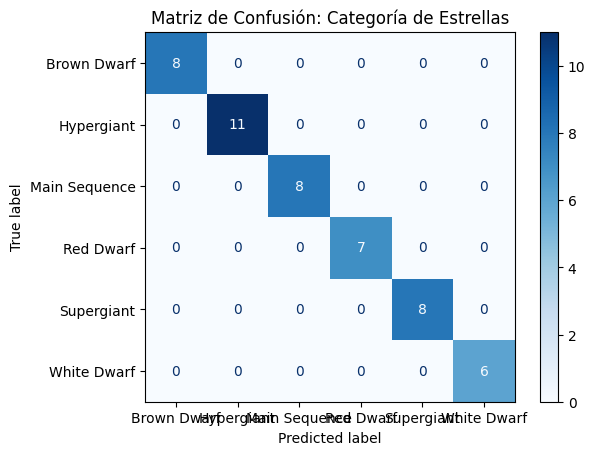

In [ ]:
# Mostramos la matriz de confusión
print("Matriz de Confusión (Test Set)")
y_pred = tree_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualización gráfica de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión: Categoría de Estrellas")
plt.show()

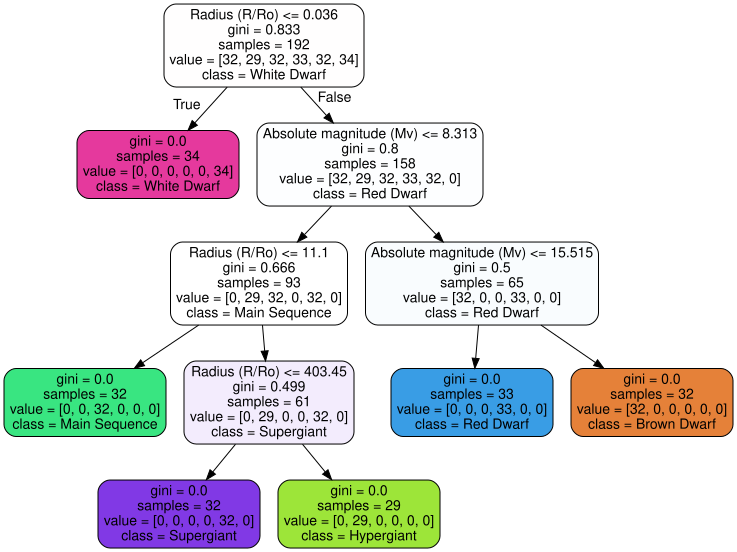

In [ ]:
# Guardamos y visualizamos el árbol
# Ruta donde se guardarán las imágenes
IMAGES_PATH = '/content/drive/My Drive/Colab Notebooks/imagenes'

# Aseguramos que la carpeta exista para evitar errores
os.makedirs(IMAGES_PATH, exist_ok=True)

export_graphviz(
    tree_clf,
    out_file=os.path.join(IMAGES_PATH, "stars.dot"),
    feature_names=Xs.columns,
    class_names=tree_clf.classes_.astype(str), # Convertimos las clases a str para evitar error de visualización
    rounded=True,
    filled=True
)

graph = Source.from_file(os.path.join(IMAGES_PATH, "stars.dot"))

graph